# Tumor Prediction — TCGA-LUAD Multi-Omics

This notebook trains and evaluates **tumour vs. normal classifiers** using three omics modalities
individually and in pairwise early-fusion combinations.

| Layer | Samples | Features |
|-------|---------|----------|
| RNASeq | 447 | 14 434 genes |
| DNAm | 420 | 384 629 CpG sites |
| CNV | 424 | 14 434 genes |

**Pipeline per experiment**
1. Variance filter — keep top *N* most variable features per modality
2. StandardScaler → fit classifier → 5-fold stratified cross-validation
3. Report AUC-ROC, Balanced Accuracy, F1 (macro), Accuracy

**Models**
- Logistic Regression (L2, class-weighted)
- Random Forest (200 trees, class-weighted)
- Linear SVM (Platt-calibrated probabilities, class-weighted)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    f1_score, accuracy_score, roc_curve, auc
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


In [2]:
DATA_DIR  = 'Group2-TCGA-LUAD-lung-adeno/'

# Variance filter: number of top features kept before PCA
N_SINGLE  = 2000   # per modality for single-omics (more features → PCA captures more variance)
N_PAIR    = 1000   # per modality for pairwise fusion

# PCA: number of components kept after decorrelation
N_PCA     = 50

CV_FOLDS  = 5
SEED      = 42

PALETTE = {
    'RNASeq':       '#4c72b0',
    'DNAm':         '#dd8452',
    'CNV':          '#55a868',
    'RNASeq+DNAm':  '#c44e52',
    'RNASeq+CNV':   '#8172b3',
    'DNAm+CNV':     '#64b5cd',
}
MODALITY_ORDER = list(PALETTE.keys())
METRIC_COLS    = ['AUC-ROC', 'Balanced Acc', 'F1 (macro)', 'Accuracy']

## 1. Load & Harmonise Data

In [3]:
meta   = pd.read_csv(DATA_DIR + 'metadata.csv')
rnaseq = pd.read_csv(DATA_DIR + 'RNASeq.csv', index_col=0)
dnam   = pd.read_csv(DATA_DIR + 'DNAm.csv',   index_col=0)
cnv    = pd.read_csv(DATA_DIR + 'CNV.csv',    index_col=0)

print('Raw shapes')
print(f'  metadata : {meta.shape}')
print(f'  RNASeq   : {rnaseq.shape}')
print(f'  DNAm     : {dnam.shape}')
print(f'  CNV      : {cnv.shape}')

Raw shapes
  metadata : (846, 7)
  RNASeq   : (447, 14434)
  DNAm     : (420, 384629)
  CNV      : (424, 14434)


In [5]:
dfs = {
    "metadata": meta,
    "RNASeq": rnaseq,
    "DNAm": dnam,
    "CNV": cnv
}

for name, df in dfs.items():
    print(f"\n{name}")
    print(f"shape: {df.shape}")
    print(f"n columns: {df.shape[1]}")
    print(f"first 10 columns: {df.columns[:10].tolist()}")
    print(f"last 10 columns: {df.columns[-10:].tolist()}")
    print(f"first 10 index values: {df.index[:10].tolist()}")


metadata
shape: (846, 7)
n columns: 7
first 10 columns: ['patient_id', 'project', 'label', 'sample_type', 'has_RNASeq', 'has_DNAm', 'has_CNV']
last 10 columns: ['patient_id', 'project', 'label', 'sample_type', 'has_RNASeq', 'has_DNAm', 'has_CNV']
first 10 index values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

RNASeq
shape: (447, 14434)
n columns: 14434
first 10 columns: ['DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2', 'GCLC', 'NFYA', 'NIPAL3', 'ENPP4']
last 10 columns: ['EXOC3L2', 'PRSS50', 'SCO2', 'C2orf81', 'TBCE', 'HULC', 'C2orf27A', 'C3orf36', 'C8orf44', 'NPBWR1']
first 10 index values: ['TCGA.69.7765', 'TCGA.44.7669', 'TCGA.91.7771', 'TCGA.05.5715', 'TCGA.64.1679', 'TCGA.86.A4P8', 'TCGA.69.7978', 'TCGA.NJ.A4YQ', 'TCGA.49.AAQV', 'TCGA.86.7714']

DNAm
shape: (420, 384629)
n columns: 384629
first 10 columns: ['cg21870274', 'cg00168193', 'cg08258224', 'cg16619049', 'cg18147296', 'cg13938959', 'cg12445832', 'cg23999112', 'cg11527153', 'cg27573606']
last 10 columns: ['cg08219170', 'cg169973

In [4]:
# Sample-ID format audit — run before harmonisation to document all formats
# and confirm there are no unresolvable ID mismatches between datasets.
print('=== Sample ID format audit (raw, before harmonisation) ===\n')

def _id_format_summary(name, idx):
    lengths = pd.Series(idx.str.len())
    has_dot  = idx.str.contains('.', regex=False).sum()
    has_dash = idx.str.contains('-').sum()
    print(f'{name}  ({len(idx)} samples)')
    print(f'  ID lengths : {sorted(lengths.unique().tolist())}')
    print(f'  Dot sep    : {has_dot}   Dash sep : {has_dash}')
    for l in sorted(lengths.unique().tolist()):
        ex = idx[lengths == l][:2].tolist()
        print(f'  len={l:2d} ({(lengths == l).sum():3d} samples)  e.g. {ex}')
    print()

_id_format_summary('metadata patient_id', pd.Index(meta['patient_id']))
_id_format_summary('RNASeq',              rnaseq.index)
_id_format_summary('DNAm',               dnam.index)
_id_format_summary('CNV',                cnv.index)

# Verify that ALL dataset IDs resolve to a known metadata sample after the new
# normalisation (same field-clip logic as cell-harmonise).
def _norm_preview(name, idx):
    """Preview normalisation: dot→dash + dataset-specific field clip."""
    idx = idx.str.replace('.', '-', regex=False)
    if name in ('RNASeq', 'DNAm'):
        idx = idx.str.split('-').str[:4].str.join('-')
        if name == 'DNAm':
            parts = idx.str.split('-')
            idx = pd.Index([
                '-'.join(p[:3]) if p[3].startswith('0') else '-'.join(p[:4])
                for p in parts
            ])
    # CNV: dot→dash only (IDs already in 3-field tumour or 4-field normal format)
    return idx

meta_set = set(meta['patient_id'].unique())
for name, idx in [('RNASeq', rnaseq.index), ('DNAm', dnam.index), ('CNV', cnv.index)]:
    normed    = _norm_preview(name, idx)
    n_miss    = (~normed.isin(meta_set)).sum()
    n_dup_raw = idx.duplicated().sum()
    # Patients with entries of more than one normalised form (3-field tumour + 4-field normal)
    pid3   = normed.str.split('-').str[:3].str.join('-')
    n_both = sum(
        1 for pid in pid3.unique()
        if len(set(normed[pid3 == pid])) > 1
    )
    print(f'{name:8s}  unresolved after norm={n_miss}  '
          f'raw dupes={n_dup_raw}  '
          f'patients with tumor+normal entries={n_both}')

=== Sample ID format audit (raw, before harmonisation) ===

metadata patient_id  (846 samples)
  ID lengths : [12, 16]
  Dot sep    : 0   Dash sep : 846
  len=12 (388 samples)  e.g. ['TCGA-69-7765', 'TCGA-44-7669']
  len=16 (458 samples)  e.g. ['TCGA-44-2655-11A', 'TCGA-55-6983-11A']

RNASeq  (447 samples)
  ID lengths : [12, 28]
  Dot sep    : 388   Dash sep : 59
  len=12 (388 samples)  e.g. ['TCGA.69.7765', 'TCGA.44.7669']
  len=28 ( 59 samples)  e.g. ['TCGA-44-2655-11A-01R-1758-07', 'TCGA-55-6983-11A-01R-1949-07']

DNAm  (420 samples)
  ID lengths : [28]
  Dot sep    : 388   Dash sep : 32
  len=28 (420 samples)  e.g. ['TCGA.69.8255.01A.11D.2285.05', 'TCGA.73.A9RS.01A.11D.A411.05']

CNV  (424 samples)
  ID lengths : [12, 16]
  Dot sep    : 424   Dash sep : 0
  len=12 (388 samples)  e.g. ['TCGA.69.7765', 'TCGA.44.7669']
  len=16 ( 36 samples)  e.g. ['TCGA.55.6983.11A', 'TCGA.55.6978.11A']

RNASeq    unresolved after norm=0  raw dupes=0  patients with tumor+normal entries=29
DNAm      

In [5]:
# Normalise TCGA sample IDs to match the patient_id format used in metadata.
#
# Metadata contains two ID formats:
#   3-field  TCGA-XX-XXXX        → patient-level tumour entry   (label = 1)
#   4-field  TCGA-XX-XXXX-11A   → sample-level normal-tissue entry (label = 0)
#
# Raw ID formats across the three source files and how they are normalised:
#
#   File    Raw example                        Normalisation              Result
#   ------  ---------------------------------  -------------------------  ------------------
#   RNASeq  TCGA.69.7765                       replace . → -             TCGA-69-7765  (3-field)
#   RNASeq  TCGA-44-2655-11A-01R-1758-07      clip to 4 fields          TCGA-44-2655-11A (4-field)
#   DNAm    TCGA.69.8255.01A.11D.2285.05      replace . → -, clip×4,   TCGA-69-8255  (3-field)
#                                               4th field '01x' → clip×3
#   DNAm    TCGA.50.5932.11A.01D.1756.05      replace . → -, clip×4    TCGA-50-5932-11A (4-field)
#   CNV     TCGA.69.7765                       replace . → -             TCGA-69-7765  (3-field)
#   CNV     TCGA.55.6983.11A                   replace . → -             TCGA-55-6983-11A (4-field)
#
# Keeping sample-level IDs means a patient with both a tumour sample (TCGA-XX-XXXX)
# and a normal-tissue sample (TCGA-XX-XXXX-11A) has TWO rows with DISTINCT IDs and
# CORRECT labels — no deduplication, no mislabelling.

# ── RNASeq ───────────────────────────────────────────────────────────────────
# Tumour IDs are already 3-field (TCGA.XX.XXXX); normal IDs are 7-field full
# barcodes (TCGA-XX-XXXX-11A-01R-YYYY-07).  Clip to 4 fields after dot→dash.
rnaseq.index = (rnaseq.index
                .str.replace('.', '-', regex=False)
                .str.split('-').str[:4].str.join('-'))

# ── DNAm ─────────────────────────────────────────────────────────────────────
# All DNAm IDs are 7-field full barcodes.  After dot→dash and 4-field clip:
#   tumour barcodes → TCGA-XX-XXXX-01A  (4th field starts with '0')
#   normal barcodes → TCGA-XX-XXXX-11A  (4th field starts with '1')
# Tumour entries need a further clip to 3 fields to match the 3-field
# patient-level IDs used for tumour entries in metadata.
dnam.index = dnam.index.str.replace('.', '-', regex=False)
dnam.index = dnam.index.str.split('-').str[:4].str.join('-')
_p = dnam.index.str.split('-')
dnam.index = pd.Index([
    '-'.join(p[:3]) if p[3].startswith('0') else '-'.join(p[:4])
    for p in _p
])

# ── CNV ──────────────────────────────────────────────────────────────────────
# CNV IDs are already in meta format (3-field tumour or 4-field normal).
# Only dot→dash normalisation required.
cnv.index = cnv.index.str.replace('.', '-', regex=False)

# ── Label map ────────────────────────────────────────────────────────────────
# Metadata already uses dashes.  Build an exact-match label map.
# Dedup handles the few cases where the same patient_id appears twice in meta.
label_map = pd.Series(meta['label'].values, index=meta['patient_id'])
label_map = label_map[~label_map.index.duplicated(keep='first')]

# ── Coverage check ───────────────────────────────────────────────────────────
print(f'Metadata label map: {len(label_map)} unique IDs')
print(f'  label=0 (Normal): {(label_map == 0).sum()}')
print(f'  label=1 (Tumour): {(label_map == 1).sum()}\n')

for name, df in [('RNASeq', rnaseq), ('DNAm', dnam), ('CNV', cnv)]:
    labels      = df.index.map(label_map)
    n_matched   = labels.notna().sum()
    n_unmatched = labels.isna().sum()
    n_normal    = int((labels == 0).sum())
    n_tumour    = int((labels == 1).sum())
    suffix = f'  WARNING: {n_unmatched} unmatched IDs' if n_unmatched else ''
    print(f'{name:8s}  {len(df):4d} samples  →  {n_matched} matched  '
          f'(Normal={n_normal}  Tumour={n_tumour}){suffix}')

Metadata label map: 846 unique IDs
  label=0 (Normal): 70
  label=1 (Tumour): 776

RNASeq     447 samples  →  447 matched  (Normal=59  Tumour=388)
DNAm       420 samples  →  420 matched  (Normal=32  Tumour=388)
CNV        424 samples  →  424 matched  (Normal=36  Tumour=388)


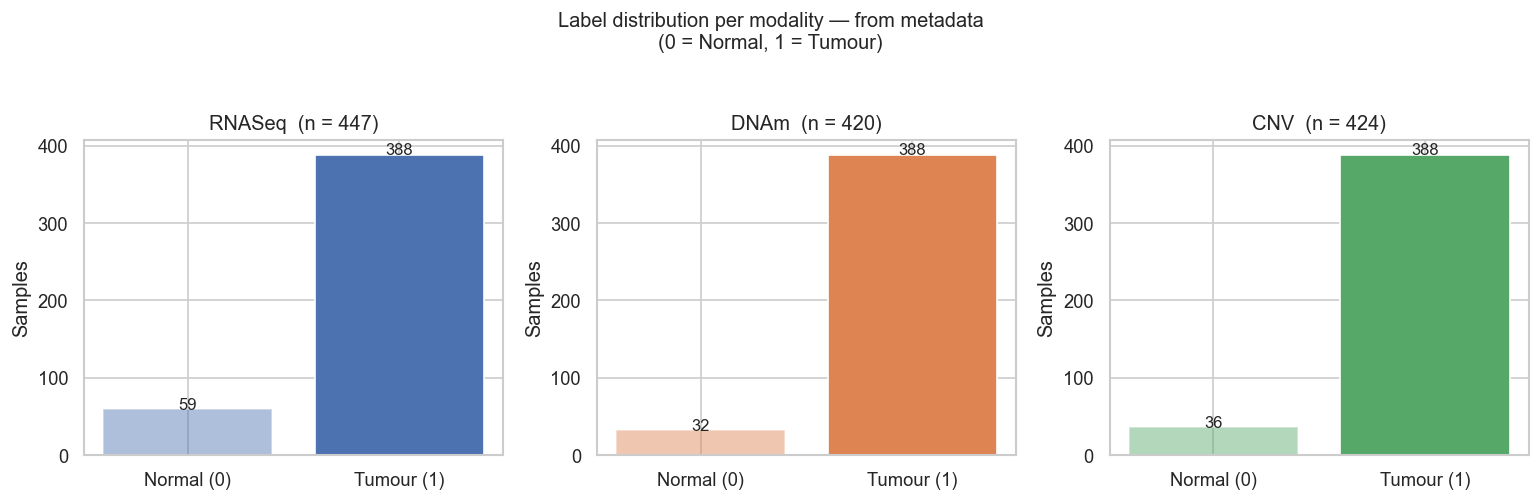

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, df) in zip(axes, [('RNASeq', rnaseq), ('DNAm', dnam), ('CNV', cnv)]):
    labels = df.index.map(label_map).dropna().astype(int)
    counts = labels.value_counts().sort_index().reindex([0, 1], fill_value=0)
    col = PALETTE[name]
    # Plot each bar separately — matplotlib bar() requires a scalar alpha, not a list
    for i, (lname, alpha) in enumerate([('Normal (0)', 0.45), ('Tumour (1)', 1.0)]):
        ax.bar(lname, counts.iloc[i], color=col, alpha=alpha)
        ax.text(i, counts.iloc[i] + 0.5, str(counts.iloc[i]), ha='center', fontsize=10)
    ax.set_title(f'{name}  (n = {len(labels)})')
    ax.set_ylabel('Samples')

plt.suptitle('Label distribution per modality — from metadata\n(0 = Normal, 1 = Tumour)',
             y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

## 2. Preprocessing & Feature Selection

The pipeline applies **two sequential dimensionality-reduction steps**:

1. **Variance filter** — retain the top *N* most variable features per modality.
   Fast unsupervised pre-filtering to a tractable range before PCA.
   For DNAm this is especially important: the 384 629 CpG sites are massively
   correlated because many belong to the same gene or regulatory region,
   so even the top-2000 subset will contain strong co-linear structure.

2. **PCA (Principal Component Analysis)** — applied *inside the sklearn pipeline*,
   fit only on training data in each CV fold to prevent leakage.
   PCA decorrelates the filtered features and compresses them into *K* orthogonal
   components that capture the dominant axes of variation.

**Pairwise early fusion** applies modality-specific scaling + PCA to each block
independently (`ColumnTransformer`), then concatenates the *K* components from
both modalities. This prevents one modality from dominating the joint feature space.

In [ ]:
def select_top_var(df, n):
    return df[df.var(axis=0).nlargest(n).index]


def prepare_single(df, label_map, n_features):
    """
    Variance filter → label lookup via patient ID → (X, y).
    Samples whose patient ID is absent from label_map are dropped.
    """
    df_sel = select_top_var(df, n_features)
    labels = df_sel.index.map(label_map)
    valid  = ~labels.isna()
    X = df_sel.loc[valid].values.astype(float)
    y = labels[valid].astype(int).values
    return X, y


def prepare_pair(df1, df2, label_map, n_features, prefix1, prefix2):
    """
    Concatenate top features from two modalities on their shared patient IDs.
    Label is looked up from metadata via the (already-normalised) patient ID.
    Samples without a metadata match are excluded.
    Dedup keeps the first measurement per patient to avoid shape mismatches
    when a dataset has multiple measurements per patient (e.g. DNAm).
    """
    sel1 = select_top_var(df1, n_features).add_prefix(prefix1 + '_')
    sel2 = select_top_var(df2, n_features).add_prefix(prefix2 + '_')
    # One row per patient — prevents .loc[shared] returning extra rows for duplicates
    sel1 = sel1[~sel1.index.duplicated(keep='first')]
    sel2 = sel2[~sel2.index.duplicated(keep='first')]
    shared = sel1.index.intersection(sel2.index)
    X      = np.hstack([sel1.loc[shared].values,
                        sel2.loc[shared].values]).astype(float)
    labels = pd.Series(shared.map(label_map), index=shared)
    valid  = ~labels.isna()
    X = X[valid.values]
    y = labels[valid].astype(int).values
    return X, y


print('Preprocessing helpers defined.')

## 3. Classifiers & Evaluation Framework

**Single-omics pipeline per fold:**
> Variance filter → StandardScaler → PCA(*K*) → Classifier

**Pairwise pipeline per fold:**
> [mod 1: Variance filter → StandardScaler → PCA(*K*)] ⊕ [mod 2: same] → Concat → Classifier

All models use `class_weight='balanced'` to handle the tumour/normal imbalance.
Regularisation strength C = 1.0 is appropriate for PCA-reduced, decorrelated features
(stronger regularisation is less necessary after PCA compression).

| Model | Regularisation | Notes |
|-------|---------------|-------|
| Logistic Regression | L2, C = 1.0 | Linear baseline |
| Random Forest | — | 200 trees, sqrt features per split |
| Linear SVM | C = 1.0 | Platt-scaled for probabilities |

**Evaluation**: 5-fold stratified CV. The scaler, PCA, and classifier are all re-fit
on training data each fold — no leakage. Predictions are pooled across folds for ROC curves.

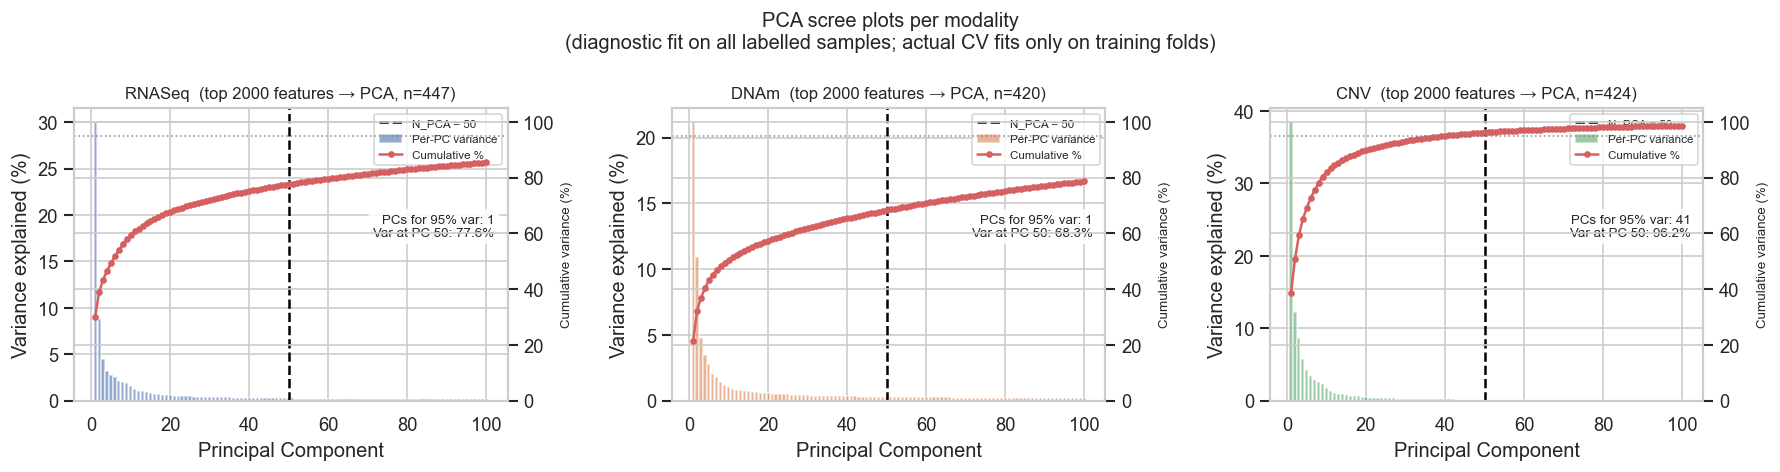

In [8]:
# PCA diagnostic: explained variance per modality
# Fitted on all labelled samples to guide the N_PCA choice.
# In the actual classification pipeline, PCA is re-fit on each training fold only.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df, col) in zip(axes, [('RNASeq', rnaseq, PALETTE['RNASeq']),
                                        ('DNAm',   dnam,   PALETTE['DNAm']),
                                        ('CNV',    cnv,    PALETTE['CNV'])]):
    labels = df.index.map(label_map)
    df_sel = select_top_var(df, N_SINGLE)
    valid  = ~labels.isna()
    X_sub  = df_sel.loc[valid].values.astype(float)

    n_show = min(N_PCA * 2, 100)
    n_comp = min(n_show, X_sub.shape[0] - 1, X_sub.shape[1])
    pca_diag = PCA(n_components=n_comp, random_state=SEED)
    pca_diag.fit(StandardScaler().fit_transform(X_sub))

    evr    = pca_diag.explained_variance_ratio_ * 100
    cumvar = np.cumsum(evr)
    xs     = range(1, len(evr) + 1)

    ax.bar(xs, evr, color=col, alpha=0.6, label='Per-PC variance')
    ax2 = ax.twinx()
    ax2.plot(xs, cumvar, 'r-o', markersize=3, lw=1.5, label='Cumulative %')
    ax2.set_ylim(0, 105)
    ax2.set_ylabel('Cumulative variance (%)', fontsize=8)

    ax.axvline(N_PCA, ls='--', color='black', lw=1.5, label=f'N_PCA = {N_PCA}')
    ax2.axhline(95, ls=':', color='grey', lw=1, alpha=0.8)

    n_for_95   = int(np.argmax(cumvar >= 95)) + 1
    cum_at_cut = cumvar[min(N_PCA - 1, len(cumvar) - 1)]
    ax.text(0.97, 0.55,
            f'PCs for 95% var: {n_for_95}\nVar at PC {N_PCA}: {cum_at_cut:.1f}%',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    ax.set_title(f'{name}  (top {N_SINGLE} features → PCA, n={valid.sum()})', fontsize=10)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Variance explained (%)')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=7, loc='upper right')

plt.suptitle('PCA scree plots per modality\n'
             '(diagnostic fit on all labelled samples; actual CV fits only on training folds)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
def make_single_models():
    """StandardScaler → PCA(N_PCA) → Classifier for single-omics data."""
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=N_PCA, random_state=SEED)),
            ('clf',    LogisticRegression(
                C=1.0, max_iter=2000, class_weight='balanced',
                solver='saga', random_state=SEED)),
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=N_PCA, random_state=SEED)),
            ('clf',    RandomForestClassifier(
                n_estimators=200, max_features='sqrt',
                class_weight='balanced', random_state=SEED, n_jobs=-1)),
        ]),
        'Linear SVM': Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=N_PCA, random_state=SEED)),
            ('clf',    SVC(kernel='linear', C=1.0, probability=True,
                           class_weight='balanced', random_state=SEED)),
        ]),
    }


def make_pair_models(n_per_modality=N_PAIR):
    """
    Per-modality StandardScaler → PCA(N_PCA) via ColumnTransformer, then Classifier.
    Each block is projected independently so neither modality dominates the joint space.
    """
    def mod_pipe():
        return Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=N_PCA, random_state=SEED)),
        ])

    classifiers = {
        'Logistic Regression': LogisticRegression(
            C=1.0, max_iter=2000, class_weight='balanced',
            solver='saga', random_state=SEED),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_features='sqrt',
            class_weight='balanced', random_state=SEED, n_jobs=-1),
        'Linear SVM': SVC(
            kernel='linear', C=1.0, probability=True,
            class_weight='balanced', random_state=SEED),
    }

    models = {}
    for mname, clf in classifiers.items():
        transform = ColumnTransformer([
            ('mod1', mod_pipe(), slice(0, n_per_modality)),
            ('mod2', mod_pipe(), slice(n_per_modality, 2 * n_per_modality)),
        ])
        models[mname] = Pipeline([('transform', transform), ('clf', clf)])
    return models


# Shared list used by downstream comparison cells
models_list = list(make_single_models().keys())


def evaluate_dataset(X, y, model_factory, n_splits=CV_FOLDS):
    """
    Stratified K-fold CV for all models from model_factory().
    Automatically reduces n_splits if the minority class is too small.
    Scaler and PCA are re-fit on each training fold only — no data leakage.
    """
    counts = np.bincount(y)
    min_class = counts.min()

    # n_splits cannot exceed the minority-class count
    effective_splits = min(n_splits, min_class)
    if effective_splits < 2:
        print(f'    WARNING: only {min_class} minority-class sample(s) — '
              f'cannot run CV, skipping this dataset.')
        nan_metrics = {k: np.nan for k in
                       ['AUC-ROC', 'AUC std', 'Balanced Acc', 'F1 (macro)', 'Accuracy']}
        dummy = {'pool_y_true': y,
                 'pool_y_score': np.full_like(y, 0.5, dtype=float)}
        return {m: {**nan_metrics, **dummy} for m in model_factory().keys()}

    if effective_splits < n_splits:
        print(f'    Note: using {effective_splits}-fold CV '
              f'(minority class has only {min_class} samples)')

    skf = StratifiedKFold(n_splits=effective_splits, shuffle=True, random_state=SEED)
    results = {}

    for mname, pipeline in model_factory().items():
        fold_aucs, fold_baccs, fold_f1s, fold_accs = [], [], [], []
        pool_y_true, pool_y_score = [], []

        for train_idx, test_idx in skf.split(X, y):
            m = clone(pipeline)
            m.fit(X[train_idx], y[train_idx])
            y_pred  = m.predict(X[test_idx])
            y_score = m.predict_proba(X[test_idx])[:, 1]

            fold_aucs.append(roc_auc_score(y[test_idx], y_score))
            fold_baccs.append(balanced_accuracy_score(y[test_idx], y_pred))
            fold_f1s.append(f1_score(y[test_idx], y_pred, average='macro'))
            fold_accs.append(accuracy_score(y[test_idx], y_pred))
            pool_y_true.extend(y[test_idx].tolist())
            pool_y_score.extend(y_score.tolist())

        results[mname] = {
            'AUC-ROC':      round(np.mean(fold_aucs),  4),
            'AUC std':      round(np.std(fold_aucs),   4),
            'Balanced Acc': round(np.mean(fold_baccs), 4),
            'F1 (macro)':   round(np.mean(fold_f1s),   4),
            'Accuracy':     round(np.mean(fold_accs),  4),
            'pool_y_true':  np.array(pool_y_true),
            'pool_y_score': np.array(pool_y_score),
        }

    return results


print('Model factories and evaluation function defined.')
print(f'  Single-omics:  StandardScaler → PCA({N_PCA}) → Classifier')
print(f'  Pairwise:      [mod1: StandardScaler → PCA({N_PCA})] ⊕ '
      f'[mod2: same] → Concat({2*N_PCA} dims) → Classifier')

Model factories and evaluation function defined.
  Single-omics:  StandardScaler → PCA(50) → Classifier
  Pairwise:      [mod1: StandardScaler → PCA(50)] ⊕ [mod2: same] → Concat(100 dims) → Classifier


## 4. Single-Omics Classification

Each modality is evaluated independently.
Pipeline per fold: variance filter (top **2 000** features) → StandardScaler → PCA (**50** components) → Classifier.

In [10]:
print(f'Feature selection: top {N_SINGLE} per modality → PCA({N_PCA})\n')

single_datasets = {
    'RNASeq': prepare_single(rnaseq, label_map, N_SINGLE),
    'DNAm':   prepare_single(dnam,   label_map, N_SINGLE),
    'CNV':    prepare_single(cnv,    label_map, N_SINGLE),
}

print('Dataset overview:')
print(f'{"Modality":<10} {"Samples":>8} {"Features":>10} {"Normal":>8} {"Tumour":>8}')
print('-' * 50)
for name, (X, y) in single_datasets.items():
    counts = np.bincount(y)
    print(f'{name:<10} {len(y):>8} {X.shape[1]:>10} {counts[0]:>8} {counts[1]:>8}')

Feature selection: top 2000 per modality → PCA(50)

Dataset overview:
Modality    Samples   Features   Normal   Tumour
--------------------------------------------------
RNASeq          447       2000       59      388
DNAm            420       2000       32      388
CNV             424       2000       36      388


In [11]:
print('Running single-omics cross-validation ...')
single_results = {}
for name, (X, y) in single_datasets.items():
    print(f'  {name} ...', end=' ', flush=True)
    single_results[name] = evaluate_dataset(X, y, make_single_models)
    best_auc = max(v['AUC-ROC'] for v in single_results[name].values())
    print(f'best AUC-ROC = {best_auc:.3f}')

print('\nDone.')

Running single-omics cross-validation ...
  RNASeq ... best AUC-ROC = 1.000
  DNAm ... best AUC-ROC = 1.000
  CNV ... best AUC-ROC = 0.861

Done.


In [12]:
rows = []
for dataset, model_res in single_results.items():
    for model, metrics in model_res.items():
        rows.append({'Dataset': dataset, 'Model': model,
                     **{k: metrics[k] for k in METRIC_COLS}})

single_summary = pd.DataFrame(rows)
print('Single-omics results (mean over 5 folds):')
display(single_summary.set_index(['Dataset', 'Model']))

Single-omics results (mean over 5 folds):


AUC-ROC  Balanced Acc  F1 (macro)  Accuracy
Dataset Model                                                           
RNASeq  Logistic Regression   1.0000        1.0000      1.0000    1.0000
        Random Forest         1.0000        1.0000      1.0000    1.0000
        Linear SVM            1.0000        1.0000      1.0000    1.0000
DNAm    Logistic Regression   1.0000        0.9987      0.9917    0.9976
        Random Forest         1.0000        0.9857      0.9917    0.9976
        Linear SVM            1.0000        1.0000      1.0000    1.0000
CNV     Logistic Regression   0.7819        0.7274      0.6925    0.8891
        Random Forest         0.8607        0.5000      0.4778    0.9151
        Linear SVM            0.7867        0.6699      0.6591    0.8962

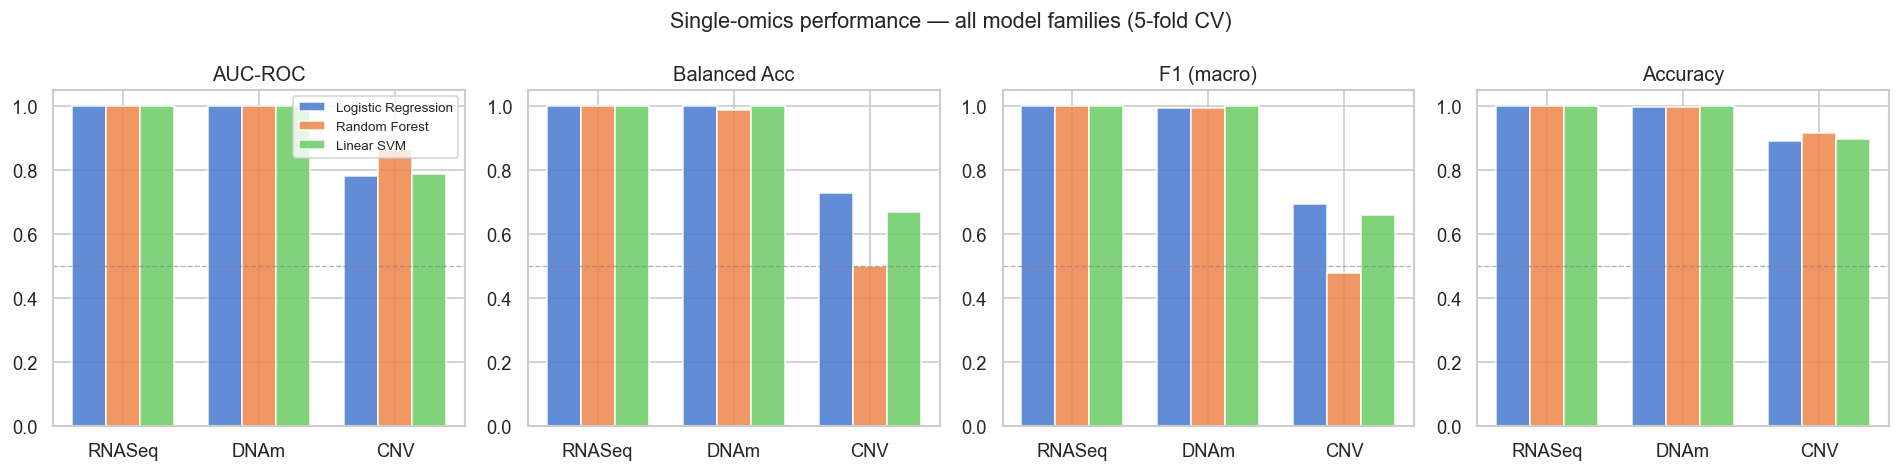

In [13]:
fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(16, 4))
x = np.arange(3)   # three single-omics modalities
width = 0.25

for ax, metric in zip(axes, METRIC_COLS):
    for i, model in enumerate(models_list):
        vals = [single_results[d][model][metric] for d in ['RNASeq', 'DNAm', 'CNV']]
        ax.bar(x + i * width, vals, width, label=model, alpha=0.85)
    ax.set_title(metric)
    ax.set_xticks(x + width)
    ax.set_xticklabels(['RNASeq', 'DNAm', 'CNV'])
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, ls='--', color='grey', lw=0.8, alpha=0.6)
    if ax is axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Single-omics performance — all model families (5-fold CV)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Pairwise Omics Combinations — Early Fusion

For each pair, the top **1 000** features from each modality are selected independently.
Each block is then scaled and projected to **50** PCA components via a `ColumnTransformer`,
giving **100** decorrelated features total before the classifier.
Only samples present in **both** modalities are used.

In [14]:
print(f'Feature selection: top {N_PAIR} per modality → per-modality PCA({N_PCA}) → {2*N_PCA} dims\n')

pair_datasets = {
    'RNASeq+DNAm': prepare_pair(rnaseq, dnam, label_map, N_PAIR, 'RNA', 'DNAm'),
    'RNASeq+CNV':  prepare_pair(rnaseq, cnv,  label_map, N_PAIR, 'RNA', 'CNV'),
    'DNAm+CNV':    prepare_pair(dnam,   cnv,  label_map, N_PAIR, 'DNAm', 'CNV'),
}

print('Dataset overview:')
print(f'{"Combination":<16} {"Samples":>8} {"Features":>10} {"Normal":>8} {"Tumour":>8}')
print('-' * 56)
for name, (X, y) in pair_datasets.items():
    counts = np.bincount(y)
    print(f'{name:<16} {len(y):>8} {X.shape[1]:>10} {counts[0]:>8} {counts[1]:>8}')

Feature selection: top 1000 per modality → per-modality PCA(50) → 100 dims

Dataset overview:
Combination       Samples   Features   Normal   Tumour
--------------------------------------------------------
RNASeq+DNAm           409       2000       21      388
RNASeq+CNV            424       2000       36      388
DNAm+CNV              397       2000        9      388


In [15]:
print('Running pairwise cross-validation ...')
pair_results = {}
for name, (X, y) in pair_datasets.items():
    print(f'  {name} ...', end=' ', flush=True)
    pair_results[name] = evaluate_dataset(X, y, lambda: make_pair_models(N_PAIR))
    best_auc = max(v['AUC-ROC'] for v in pair_results[name].values())
    print(f'best AUC-ROC = {best_auc:.3f}')

print('\nDone.')

Running pairwise cross-validation ...
  RNASeq+DNAm ... best AUC-ROC = 1.000
  RNASeq+CNV ... best AUC-ROC = 1.000
  DNAm+CNV ... best AUC-ROC = 1.000

Done.


In [16]:
rows = []
for dataset, model_res in pair_results.items():
    for model, metrics in model_res.items():
        rows.append({'Dataset': dataset, 'Model': model,
                     **{k: metrics[k] for k in METRIC_COLS}})

pair_summary = pd.DataFrame(rows)
print('Pairwise combination results (mean over 5 folds):')
display(pair_summary.set_index(['Dataset', 'Model']))

Pairwise combination results (mean over 5 folds):


AUC-ROC  Balanced Acc  F1 (macro)  Accuracy
Dataset     Model                                                           
RNASeq+DNAm Logistic Regression      1.0        0.9871      0.9059    0.9756
            Random Forest            1.0        1.0000      1.0000    1.0000
            Linear SVM               1.0        1.0000      1.0000    1.0000
RNASeq+CNV  Logistic Regression      1.0        0.9961      0.9788    0.9929
            Random Forest            1.0        0.9857      0.9917    0.9976
            Linear SVM               1.0        1.0000      1.0000    1.0000
DNAm+CNV    Logistic Regression      1.0        0.9987      0.9660    0.9975
            Random Forest            1.0        0.8500      0.8981    0.9925
            Linear SVM               1.0        0.8500      0.8981    0.9924

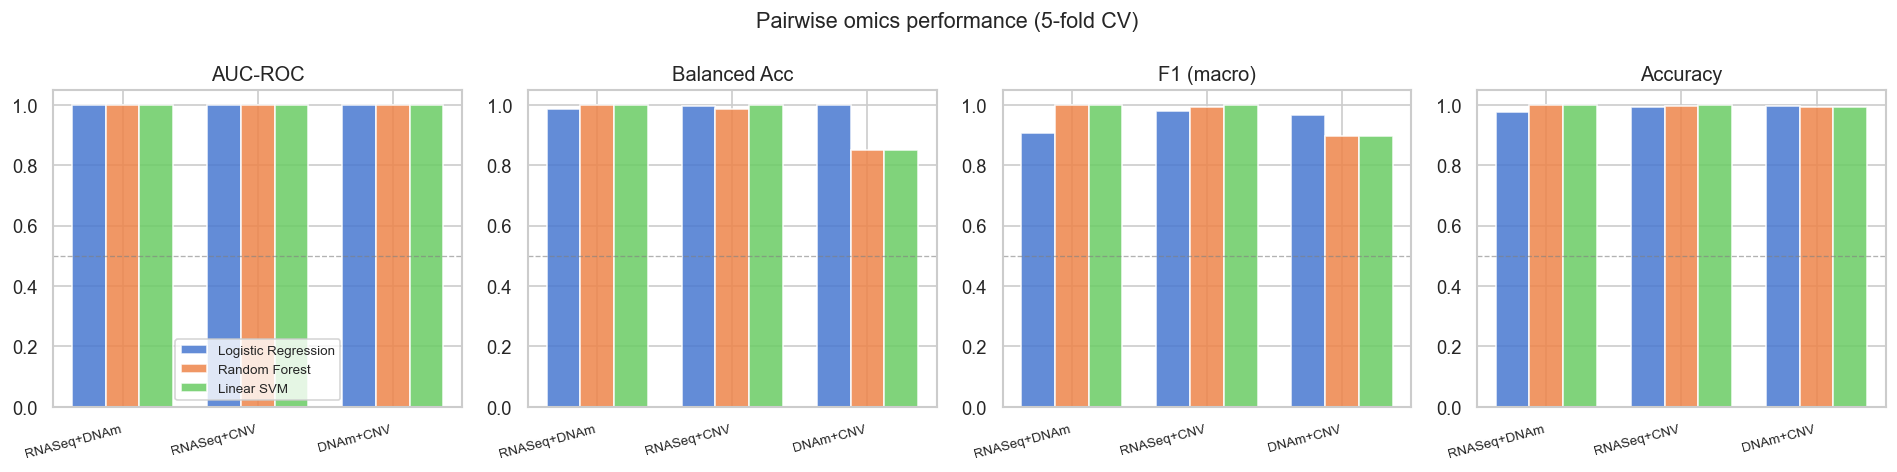

In [17]:
fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(16, 4))
pair_names = ['RNASeq+DNAm', 'RNASeq+CNV', 'DNAm+CNV']
x = np.arange(3)

for ax, metric in zip(axes, METRIC_COLS):
    for i, model in enumerate(models_list):
        vals = [pair_results[d][model][metric] for d in pair_names]
        ax.bar(x + i * width, vals, width, label=model, alpha=0.85)
    ax.set_title(metric)
    ax.set_xticks(x + width)
    ax.set_xticklabels(pair_names, rotation=15, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, ls='--', color='grey', lw=0.8, alpha=0.6)
    if ax is axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Pairwise omics performance (5-fold CV)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Comparative Analysis

All six configurations side-by-side — single omics vs. pairwise combinations.

In [18]:
all_results  = {**single_results, **pair_results}
all_summary  = pd.concat([single_summary, pair_summary], ignore_index=True)

print('Full results — all modalities and models (mean 5-fold CV):')
display(
    all_summary
    .set_index(['Dataset', 'Model'])
    .style.background_gradient(cmap='YlOrRd', subset=METRIC_COLS, axis=None)
    .format('{:.3f}')
)

Full results — all modalities and models (mean 5-fold CV):


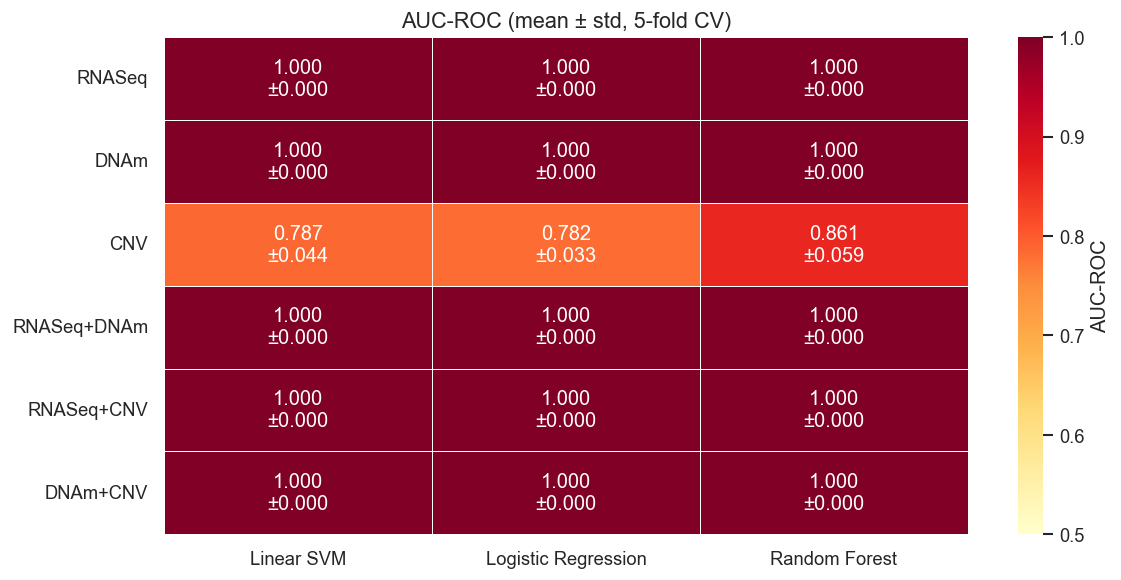

In [19]:
# AUC-ROC heatmap: rows = modality, columns = model
pivot_auc = (
    all_summary
    .pivot(index='Dataset', columns='Model', values='AUC-ROC')
    .reindex(MODALITY_ORDER)
)

# Add AUC std as annotation text
pivot_std = (
    all_summary.assign(**{'AUC std': all_summary['Dataset'].map(
        {d: {m: all_results[d][m]['AUC std'] for m in models_list}
         for d in MODALITY_ORDER}
    )})
)

annot = pivot_auc.copy().astype(str)
for dataset in MODALITY_ORDER:
    for model in models_list:
        mu  = all_results[dataset][model]['AUC-ROC']
        std = all_results[dataset][model]['AUC std']
        annot.loc[dataset, model] = f'{mu:.3f}\n±{std:.3f}'

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_auc, annot=annot, fmt='', cmap='YlOrRd',
    vmin=0.5, vmax=1.0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'AUC-ROC'}
)
ax.set_title('AUC-ROC (mean ± std, 5-fold CV)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

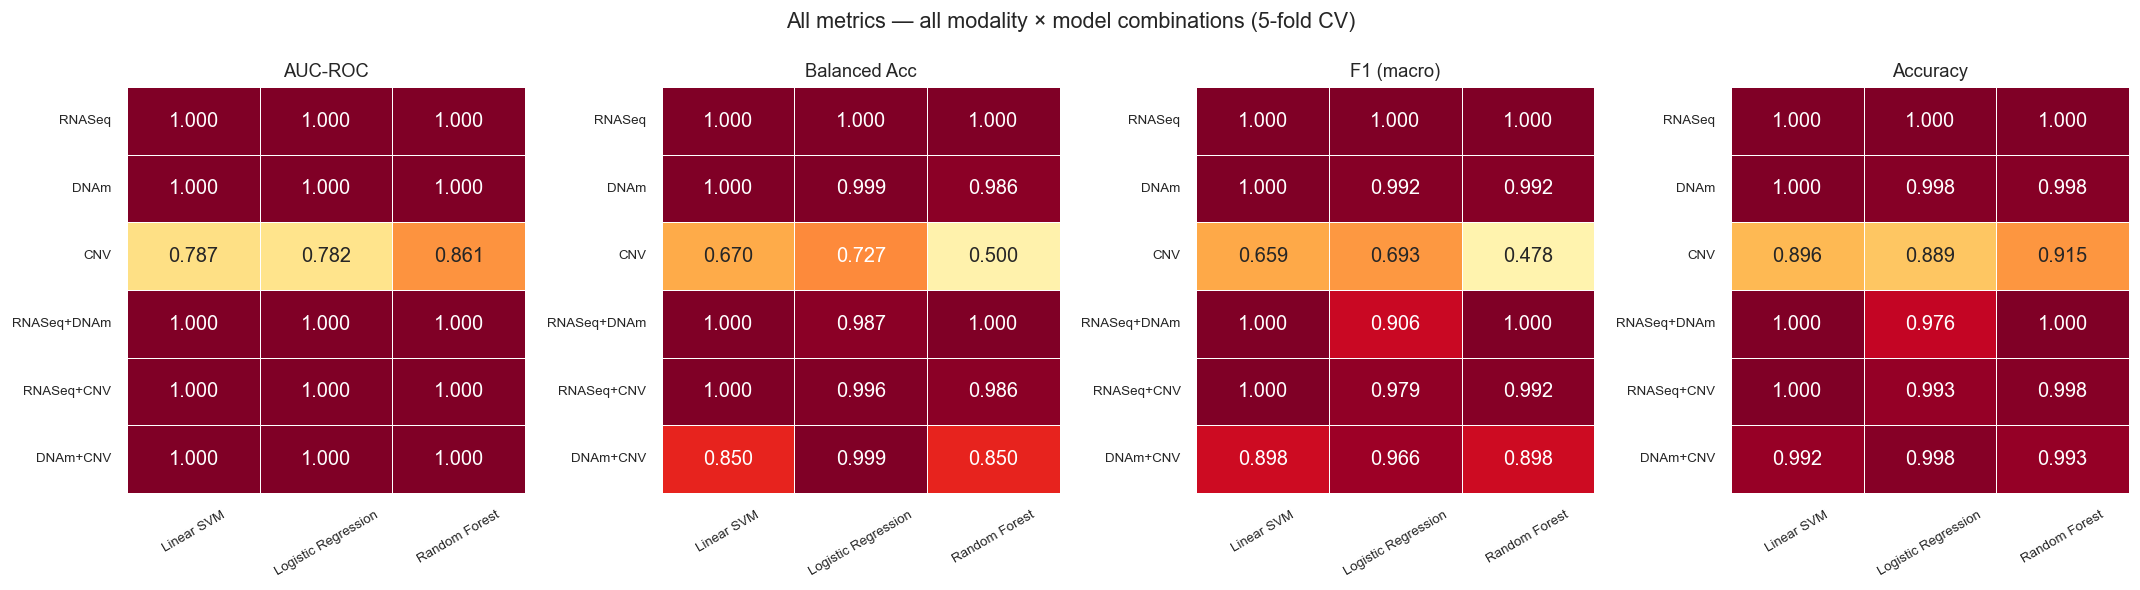

In [20]:
# One heatmap per metric — best model highlighted
fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(18, 5))

for ax, metric in zip(axes, METRIC_COLS):
    pivot = (
        all_summary
        .pivot(index='Dataset', columns='Model', values=metric)
        .reindex(MODALITY_ORDER)
    )
    sns.heatmap(
        pivot, annot=True, fmt='.3f', cmap='YlOrRd',
        vmin=max(0, pivot.values.min() - 0.05), vmax=1.0,
        linewidths=0.4, ax=ax, cbar=False
    )
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('All metrics — all modality × model combinations (5-fold CV)', fontsize=13)
plt.tight_layout()
plt.show()

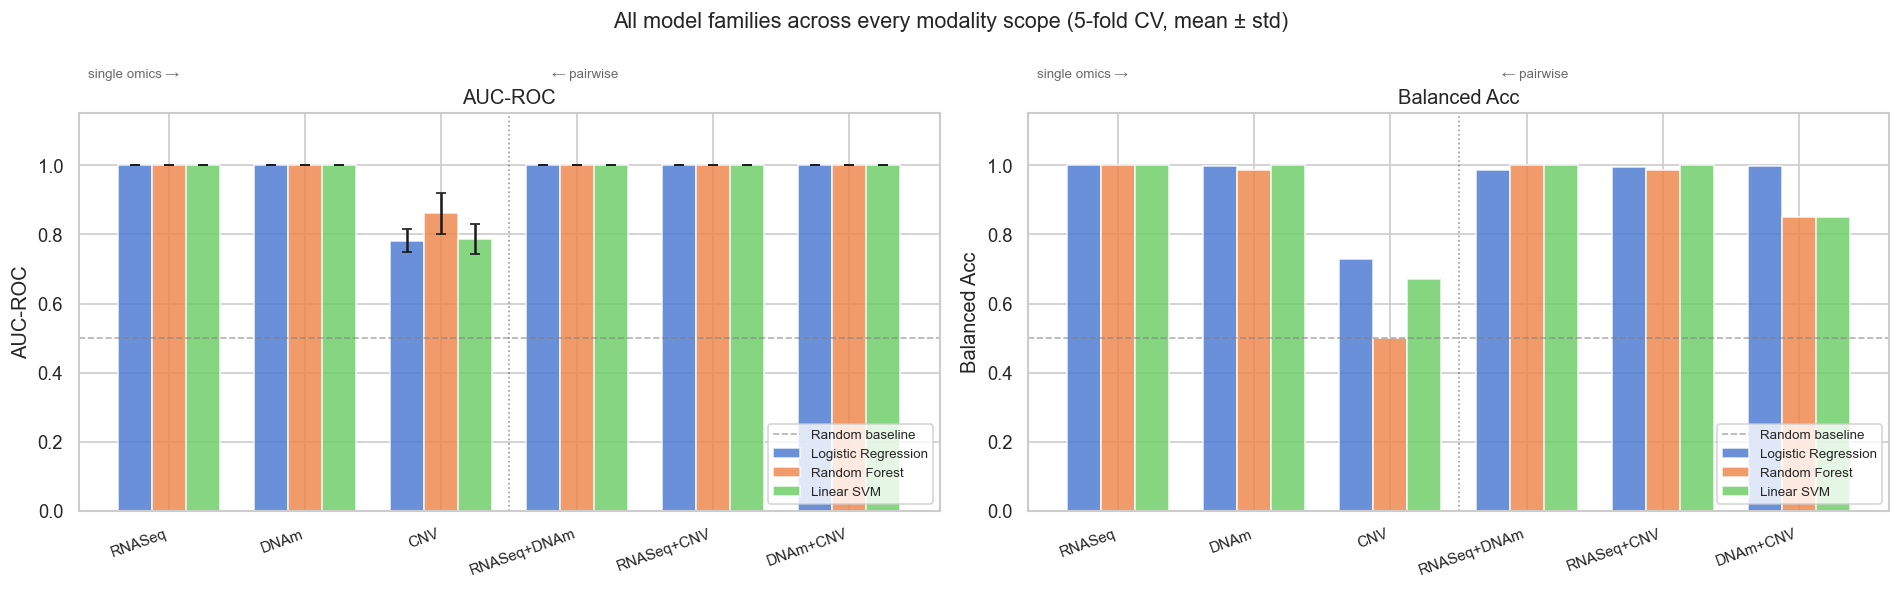

In [21]:
# AUC-ROC grouped bar — all model families × all modality scopes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x     = np.arange(len(MODALITY_ORDER))
width = 0.25
model_colors = ['#4878d0', '#ee854a', '#6acc65']   # LR, RF, SVM

for ax, metric in zip(axes, ['AUC-ROC', 'Balanced Acc']):
    for i, (model, mc) in enumerate(zip(models_list, model_colors)):
        vals = [all_results[d][model][metric] for d in MODALITY_ORDER]
        errs = [all_results[d][model]['AUC std'] for d in MODALITY_ORDER] \
               if metric == 'AUC-ROC' else None
        ax.bar(x + i * width, vals, width, label=model,
               color=mc, alpha=0.82, edgecolor='white',
               yerr=errs, capsize=3)

    ax.set_xticks(x + width)
    ax.set_xticklabels(MODALITY_ORDER, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.axhline(0.5, ls='--', color='grey', lw=1, alpha=0.6, label='Random baseline')
    # divider between single and pairwise regions
    ax.axvline(2.75, ls=':', color='black', lw=1, alpha=0.4)
    ax.annotate('single omics →', xy=(0.01, 1.09), xycoords='axes fraction',
                fontsize=8, color='dimgrey')
    ax.annotate('← pairwise', xy=(0.55, 1.09), xycoords='axes fraction',
                fontsize=8, color='dimgrey')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('All model families across every modality scope (5-fold CV, mean ± std)',
             fontsize=13)
plt.tight_layout()
plt.show()

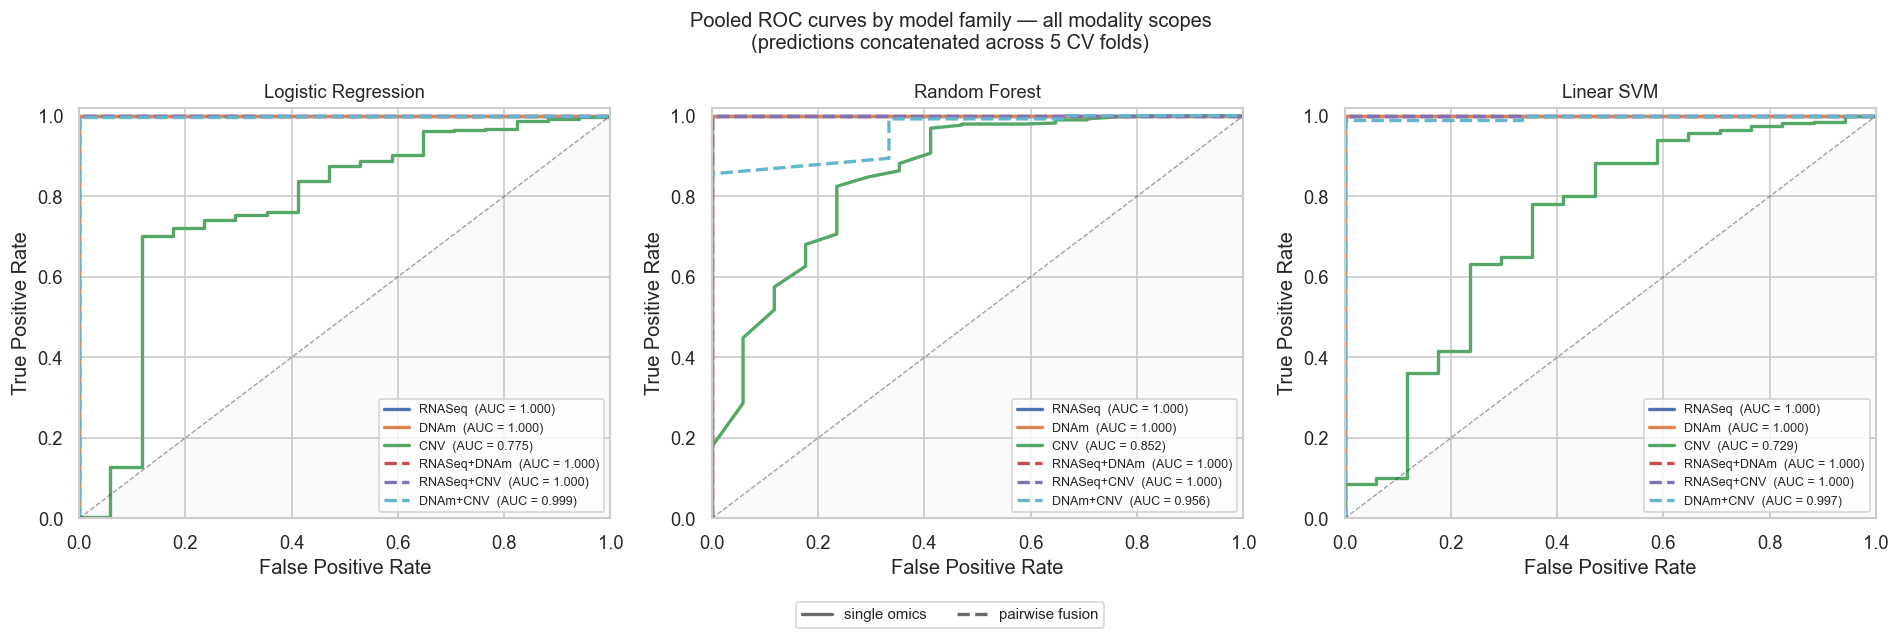

In [24]:
# Pooled ROC curves — one panel per model family, all 6 scopes overlaid
# Solid lines = single omics, dashed = pairwise combinations
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model in zip(axes, models_list):
    for name in MODALITY_ORDER:
        d = all_results[name][model]
        fpr, tpr, _ = roc_curve(d['pool_y_true'], d['pool_y_score'])
        roc_val = auc(fpr, tpr)
        ls = '-' if name in ['RNASeq', 'DNAm', 'CNV'] else '--'
        ax.plot(fpr, tpr, color=PALETTE[name], lw=2, ls=ls,
                label=f'{name}  (AUC = {roc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4)
    ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
    ax.set_title(model, fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7.5, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

# Shared legend for line styles
style_handles = [
    Line2D([0], [0], color='dimgrey', lw=2, ls='-',  label='single omics'),
    Line2D([0], [0], color='dimgrey', lw=2, ls='--', label='pairwise fusion'),
]
fig.legend(handles=style_handles, loc='lower center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.suptitle('Pooled ROC curves by model family — all modality scopes\n'
             '(predictions concatenated across 5 CV folds)', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# Best model per modality ranked by AUC-ROC
best_per_dataset = (
    all_summary
    .sort_values('AUC-ROC', ascending=False)
    .groupby('Dataset', sort=False)
    .first()
    [['Model'] + METRIC_COLS]
    .reindex(MODALITY_ORDER)
)

print('Best model per configuration (ranked by AUC-ROC):')
display(best_per_dataset)

Best model per configuration (ranked by AUC-ROC):


,Model,AUC-ROC,Balanced Acc,F1 (macro),Accuracy
Dataset,,,,,
RNASeq,Logistic Regression,1.0000,1.00,1.0000,1.0000
DNAm,Linear SVM,1.0000,1.00,1.0000,1.0000
CNV,Random Forest,0.8607,0.50,0.4778,0.9151
RNASeq+DNAm,Linear SVM,1.0000,1.00,1.0000,1.0000
RNASeq+CNV,Linear SVM,1.0000,1.00,1.0000,1.0000
DNAm+CNV,Random Forest,1.0000,0.85,0.8981,0.9925


In [23]:
# Gain from pairwise fusion vs. best single-omics constituent
pair_to_singles = {
    'RNASeq+DNAm': ('RNASeq', 'DNAm'),
    'RNASeq+CNV':  ('RNASeq', 'CNV'),
    'DNAm+CNV':    ('DNAm',   'CNV'),
}

rows = []
for pair, (s1, s2) in pair_to_singles.items():
    for model in models_list:
        auc_pair = all_results[pair][model]['AUC-ROC']
        auc_best = max(all_results[s1][model]['AUC-ROC'],
                       all_results[s2][model]['AUC-ROC'])
        rows.append({
            'Combination': pair,
            'Model':       model,
            'Best single AUC': round(auc_best,       4),
            'Pair AUC':        round(auc_pair,        4),
            'ΔAUC':            round(auc_pair - auc_best, 4),
        })

delta_df = pd.DataFrame(rows)
print('AUC-ROC gain from early fusion (pair − best single constituent):')
display(delta_df.set_index(['Combination', 'Model']).style.bar(
    subset=['ΔAUC'], align='zero', color=['#d65f5f', '#5fba7d']
))

AUC-ROC gain from early fusion (pair − best single constituent):


## 7. DIABLO — Supervised Multi-Omics Integration (all 3 layers)

[DIABLO](https://mixomics.org/methods/diablo/) (`block.splsda` in the `mixOmics` R package)
is a supervised multi-block sparse PLS-DA method. Unlike the pairwise early-fusion pipelines
above, DIABLO integrates **all three omics layers simultaneously** by maximising the
covariance between blocks while retaining discriminant power for the class labels.

Key differences from the sklearn pipeline:

- **No PCA pre-compression**: DIABLO performs its own sparse latent-factor decomposition.
- **Cross-block covariance**: a design matrix controls how strongly blocks are allowed to
  co-vary — off-diagonal entries of 0.1 encourage information sharing without forcing
  identical projections.
- **Feature selection built-in**: `keepX` controls how many features are selected per block
  per component; here 50 features per block.

Performance is estimated by 3-fold × 10-repeat CV via `perf()` — 3 folds because
only 3 Normal samples remain in the shared three-modality intersection (consistent with
how the sklearn pipeline auto-reduces folds for DNAm+CNV).
DIABLO is called from Python via **rpy2** — no PyTorch required.

In [24]:
# ── 7.0  Optional: install mixOmics (run ONCE per environment) ───────────────
# Skip this cell if cell 7.1 prints "mixOmics X.Y loaded."
# mixOmics is a Bioconductor package; installation takes ~5 minutes.
# Uncomment the block below and run it, then re-run cell 7.1.

# import rpy2.robjects as ro
# ro.r("""
#     if (!requireNamespace('BiocManager', quietly = TRUE))
#         install.packages('BiocManager', repos = 'https://cloud.r-project.org')
#     if (!requireNamespace('mixOmics', quietly = TRUE))
#         BiocManager::install('mixOmics', ask = FALSE, update = FALSE)
# """)
# print('mixOmics installation complete — re-run cell 7.1 to verify.')

print('Cell 7.0: optional install cell — uncomment and run only if mixOmics is missing.')

Cell 7.0: optional install cell — uncomment and run only if mixOmics is missing.


In [25]:
# ── 7.1  Setup: load mixOmics via rpy2 ───────────────────────────────────────
# R 4.5.3 and rpy2 3.6.7 are pre-installed in SysCompBio_tf.
# Install mixOmics once via cell 7.0 if DIABLO_AVAILABLE = False below.

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import rpy2.robjects.packages as rpackages

DIABLO_AVAILABLE = False
try:
    mixomics = rpackages.importr('mixOmics')
    ver = ro.r('as.character(packageVersion("mixOmics"))')[0]
    print(f'mixOmics {ver} loaded.')
    DIABLO_AVAILABLE = True
except Exception as e:
    print(f'mixOmics not available: {e}')
    print('Uncomment and run cell 7.0 to install it, then re-run this cell.')

print(f'\nDIABLO available: {DIABLO_AVAILABLE}')

mixOmics 6.32.0 loaded.

DIABLO available: True


In [26]:
# ── 7.2  Data preparation ─────────────────────────────────────────────────────
# DIABLO requires all three modalities to share the same row order.
# Use only patients present in ALL three harmonised dataframes with metadata labels.

if not DIABLO_AVAILABLE:
    print('Skipping data prep — mixOmics not available (run cells 7.0 and 7.1 first).')
else:
    # Dedup to one measurement per patient before computing the intersection
    # (DNAm can have multiple tumor measurements per patient after normalisation)
    rna_dd  = rnaseq[~rnaseq.index.duplicated(keep='first')]
    dnam_dd = dnam[~dnam.index.duplicated(keep='first')]
    cnv_dd  = cnv[~cnv.index.duplicated(keep='first')]

    # Intersection of patients with all 3 modalities + metadata label
    shared = (rna_dd.index
              .intersection(dnam_dd.index)
              .intersection(cnv_dd.index))
    lbl_shared = pd.Series(shared.map(label_map), index=shared)
    shared = shared[~lbl_shared.isna()]
    y_shared = lbl_shared.dropna().astype(int).values

    print(f'Shared patients (all 3 modalities + metadata): {len(shared)}')
    print(f'  Normal (0): {(y_shared == 0).sum()}   Tumour (1): {(y_shared == 1).sum()}')

    # Variance filter — same N_PAIR features as pairwise experiments
    rna_f  = select_top_var(rna_dd.loc[shared],  N_PAIR)
    dnam_f = select_top_var(dnam_dd.loc[shared], N_PAIR)
    cnv_f  = select_top_var(cnv_dd.loc[shared],  N_PAIR)

    print(f'\nFeatures per block after variance filter (top {N_PAIR}):')
    print(f'  RNASeq : {rna_f.shape[1]}')
    print(f'  DNAm   : {dnam_f.shape[1]}')
    print(f'  CNV    : {cnv_f.shape[1]}')

    # Convert DataFrames to R matrices
    with localconverter(ro.default_converter + pandas2ri.converter):
        r_rna  = ro.conversion.py2rpy(rna_f)
        r_dnam = ro.conversion.py2rpy(dnam_f)
        r_cnv  = ro.conversion.py2rpy(cnv_f)

    # R factor: labels as 'Normal' / 'Tumour'
    y_labels = ['Normal' if v == 0 else 'Tumour' for v in y_shared]
    r_Y = ro.FactorVector(ro.StrVector(y_labels))

    # Push to R global environment
    ro.globalenv['r_rna']  = r_rna
    ro.globalenv['r_dnam'] = r_dnam
    ro.globalenv['r_cnv']  = r_cnv
    ro.globalenv['r_Y']    = r_Y
    ro.r('X_list <- list(RNASeq = r_rna, DNAm = r_dnam, CNV = r_cnv)')

    print('\nR objects created: X_list (3 blocks) and Y factor — ready for DIABLO.')

Shared patients (all 3 modalities + metadata): 397
  Normal (0): 9   Tumour (1): 388

Features per block after variance filter (top 1000):
  RNASeq : 1000
  DNAm   : 1000
  CNV    : 1000

R objects created: X_list (3 blocks) and Y factor — ready for DIABLO.


In [27]:
# ── 7.3  Fit DIABLO and estimate performance ──────────────────────────────────
# Design matrix: off-diagonal 0.1 → moderate cross-block covariance.
# ncomp = 2 latent components; keepX = 50 features per block per component.
# perf(): 3-fold × 10-repeat CV — 3 folds because only 3 Normal samples exist
# in the shared intersection (same logic as the sklearn pipeline's auto-reduce).

diablo_perf = None

if not DIABLO_AVAILABLE:
    print('Skipping DIABLO fit — mixOmics not available.')
else:
    print('Fitting DIABLO (block.splsda, ncomp=2, keepX=50 per block) ...')
    ro.r("""
        design <- matrix(0.1,
            nrow = length(X_list), ncol = length(X_list),
            dimnames = list(names(X_list), names(X_list)))
        diag(design) <- 0

        diablo_fit <- block.splsda(
            X      = X_list,
            Y      = r_Y,
            ncomp  = 2,
            keepX  = list(RNASeq = c(50, 50), DNAm = c(50, 50), CNV = c(50, 50)),
            design = design
        )
    """)
    print('Model fitted.')
    print('Running cross-validation (3 folds × 10 repeats) — this takes a few minutes ...')

    ro.r("""
        set.seed(42)
        diablo_perf_obj <- perf(
            diablo_fit,
            validation = 'Mfold',
            folds      = 3,
            nrepeat    = 10,
            auc        = TRUE
        )
    """)
    diablo_perf = ro.globalenv['diablo_perf_obj']
    print('Cross-validation complete.')

R callback write-console: Design matrix has changed to include Y; each block will be
            linked to Y.
  


Fitting DIABLO (block.splsda, ncomp=2, keepX=50 per block) ...
Model fitted.
Running cross-validation (3 folds × 10 repeats) — this takes a few minutes ...
Cross-validation complete.


DIABLO (averaged predictions, comp 2):
  AUC-ROC      : 0.9522
  Balanced Acc : 0.5  (= 1 − BER, AveragedPredict)

=== DIABLO vs best sklearn-pipeline model ===
Note: sklearn metrics = 5-fold CV mean; DIABLO = 3-fold × 10-repeat CV.



,Model,AUC-ROC,Balanced Acc,F1 (macro),Accuracy
Dataset,,,,,
RNASeq,Logistic Regression,1.000,1.000,1.000,1.000
DNAm+CNV,Random Forest,1.000,0.850,0.898,0.993
RNASeq+CNV,Linear SVM,1.000,1.000,1.000,1.000
RNASeq+DNAm,Linear SVM,1.000,1.000,1.000,1.000
DNAm,Linear SVM,1.000,1.000,1.000,1.000
CNV,Random Forest,0.861,0.500,0.478,0.915
DIABLO (all 3),block.splsda,0.952,0.500,—,—


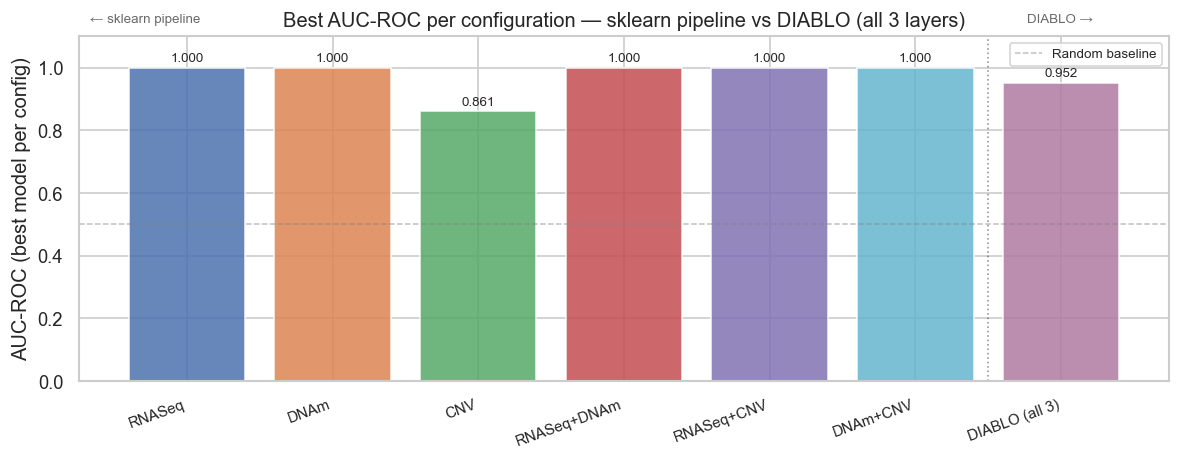

In [28]:
# ── 7.4  Results: DIABLO vs sklearn pipeline ─────────────────────────────────
# perf() object structure (mixOmics 6.x):
#   auc$comp2[, "AUC"]                                — AUC per class pair at comp 2
#   AveragedPredict.error.rate["Overall.BER", "comp2"] — balanced error rate at comp 2

if not DIABLO_AVAILABLE or diablo_perf is None:
    print('Skipping results — DIABLO not run (run cells 7.1–7.3 first).')
else:
    diablo_auc = float(ro.r(
        'mean(diablo_perf_obj$auc$comp2[, "AUC"])'
    )[0])
    diablo_ber = float(ro.r(
        'diablo_perf_obj$AveragedPredict.error.rate["Overall.BER", "comp2"]'
    )[0])
    diablo_bal_acc = round(1.0 - diablo_ber, 4)
    diablo_auc     = round(diablo_auc, 4)

    print(f'DIABLO (averaged predictions, comp 2):')
    print(f'  AUC-ROC      : {diablo_auc}')
    print(f'  Balanced Acc : {diablo_bal_acc}  (= 1 − BER, AveragedPredict)')

    diablo_metrics = {
        'AUC-ROC':      diablo_auc,
        'Balanced Acc': diablo_bal_acc,
        'F1 (macro)':   float('nan'),
        'Accuracy':     float('nan'),
    }
    diablo_row = pd.DataFrame([{
        'Dataset': 'DIABLO (all 3)', 'Model': 'block.splsda', **diablo_metrics
    }])

    # Best model per configuration from the sklearn pipeline
    best_pipeline = (
        all_summary
        .sort_values('AUC-ROC', ascending=False)
        .groupby('Dataset', sort=False)
        .first()[['Model'] + METRIC_COLS]
        .reset_index()
        .reindex(columns=['Dataset', 'Model'] + METRIC_COLS)
    )
    compare_df = pd.concat([best_pipeline, diablo_row], ignore_index=True)

    print('\n=== DIABLO vs best sklearn-pipeline model ===')
    print('Note: sklearn metrics = 5-fold CV mean; DIABLO = 3-fold × 10-repeat CV.\n')
    display(compare_df.set_index('Dataset').style
            .format('{:.3f}', na_rep='—', subset=METRIC_COLS)
            .highlight_max(subset=['AUC-ROC', 'Balanced Acc'], axis=0, color='#c6efce'))

    # Bar chart — best AUC-ROC per config including DIABLO
    cfg_order = list(MODALITY_ORDER) + ['DIABLO (all 3)']
    auc_vals  = []
    for cfg in cfg_order:
        if cfg == 'DIABLO (all 3)':
            auc_vals.append(diablo_auc)
        else:
            auc_vals.append(max(all_results[cfg][m]['AUC-ROC'] for m in models_list))

    colors = [PALETTE.get(c, '#b07aa1') for c in cfg_order]
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(cfg_order, auc_vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, ls='--', color='grey', lw=0.9, alpha=0.5, label='Random baseline')
    ax.axvline(5.5, ls=':', color='black', lw=1, alpha=0.4)
    ax.annotate('← sklearn pipeline', xy=(0.01, 1.04), xycoords='axes fraction',
                fontsize=8, color='dimgrey')
    ax.annotate('DIABLO →', xy=(0.87, 1.04), xycoords='axes fraction',
                fontsize=8, color='dimgrey')
    for bar, val in zip(bars, auc_vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.3f}',
                    ha='center', va='bottom', fontsize=8)
    ax.set_ylabel('AUC-ROC (best model per config)')
    ax.set_xticklabels(cfg_order, rotation=20, ha='right', fontsize=9)
    ax.set_title('Best AUC-ROC per configuration — sklearn pipeline vs DIABLO (all 3 layers)',
                 fontsize=12)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 8. Key Findings & Discussion

*(Complete after running the notebook — use the cells above to fill in the blanks.)*

### Questions to address

1. **Most informative single modality**: Which layer (RNASeq / DNAm / CNV) achieves
   the highest AUC-ROC? Is this consistent across all three models?

2. **Fusion benefit**: Does combining two modalities improve over the best single
   constituent? By how much (see the ΔAUC table)?

3. **DIABLO vs early fusion**: Does DIABLO (simultaneous integration of all three layers
   with cross-block covariance) outperform PCA-based pairwise early fusion?
   Is the improvement driven by the third modality, the joint latent structure, or both?

4. **Model comparison**: Which sklearn classifier is most robust (smallest AUC std across folds)?
   Does the choice of model matter more or less than the choice of modality?

5. **Class imbalance**: Accuracy can be misleading when classes are unequal.
   How does Balanced Accuracy compare to raw Accuracy across configurations?

6. **Limitations**:
   - Early fusion ignores modality-specific structure; DIABLO addresses this via the
     design matrix, but sparse PLS-DA still imposes linearity assumptions.
   - Feature selection by variance is unsupervised and may not pick the most
     discriminative features.
   - Pairwise combinations use fewer samples (intersection only), which can affect
     model stability.
   - DIABLO's F1 and raw Accuracy are not directly extracted from `perf()`;
     comparison to sklearn models on those metrics is therefore incomplete.